In [ ]:
from pathlib import Path
import warnings

import rdkit
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Descriptors, rdMolDescriptors, rdFingerprintGenerator
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Relative output directory
RESULTS_DIR = Path("../Results/Physicochemical")

print(f"rdkit version: {rdkit.__version__}")
print(f"Results directory: {RESULTS_DIR}")

rdkit version: 2025.03.4
Results directory: ../Results/Physicochemical


In [ ]:
# Preferred database order for all plots
ordre_desired = ["HsDHODH_Druglike", "HsDHODH_HighDiv"]

In [ ]:
df_druglike = pd.read_csv("../Datasets/concat_datasets_druglike.csv")
df_highdiv = pd.read_csv("../Datasets/concat_datasets_highdiv.csv")

df_druglike["Database"] = "HsDHODH_Druglike"
df_highdiv["Database"] = "HsDHODH_HighDiv"

df_complete = pd.concat([df_druglike, df_highdiv], ignore_index=True)

smi_druglike = df_druglike["SMILES"].dropna().tolist()
smi_highdiv = df_highdiv["SMILES"].dropna().tolist()

print(f"Total compounds: {len(df_complete)}")

Total compounds: 4406


In [ ]:
# Fingerprint utility functions
def ECFP(smi, r):
    fps = []
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=1024)
    for x in smi:
        mol = Chem.MolFromSmiles(x)
        if mol is None:
            continue
        fps.append([int(y) for y in generator.GetFingerprint(mol).ToBitString()])
    if not fps:
        return np.array([])
    fps_df = pd.DataFrame(fps)
    return 1 - pdist(fps_df[list(range(1024))], metric="jaccard")


def MACCSkeys_fp(smi):
    fps = []
    for x in smi:
        mol = Chem.MolFromSmiles(x)
        if mol is None:
            continue
        fps.append([int(y) for y in MACCSkeys.GenMACCSKeys(mol).ToBitString()])
    if not fps:
        return np.array([])
    fps_df = pd.DataFrame(fps)
    return 1 - pdist(fps_df[list(range(167))], metric="jaccard")

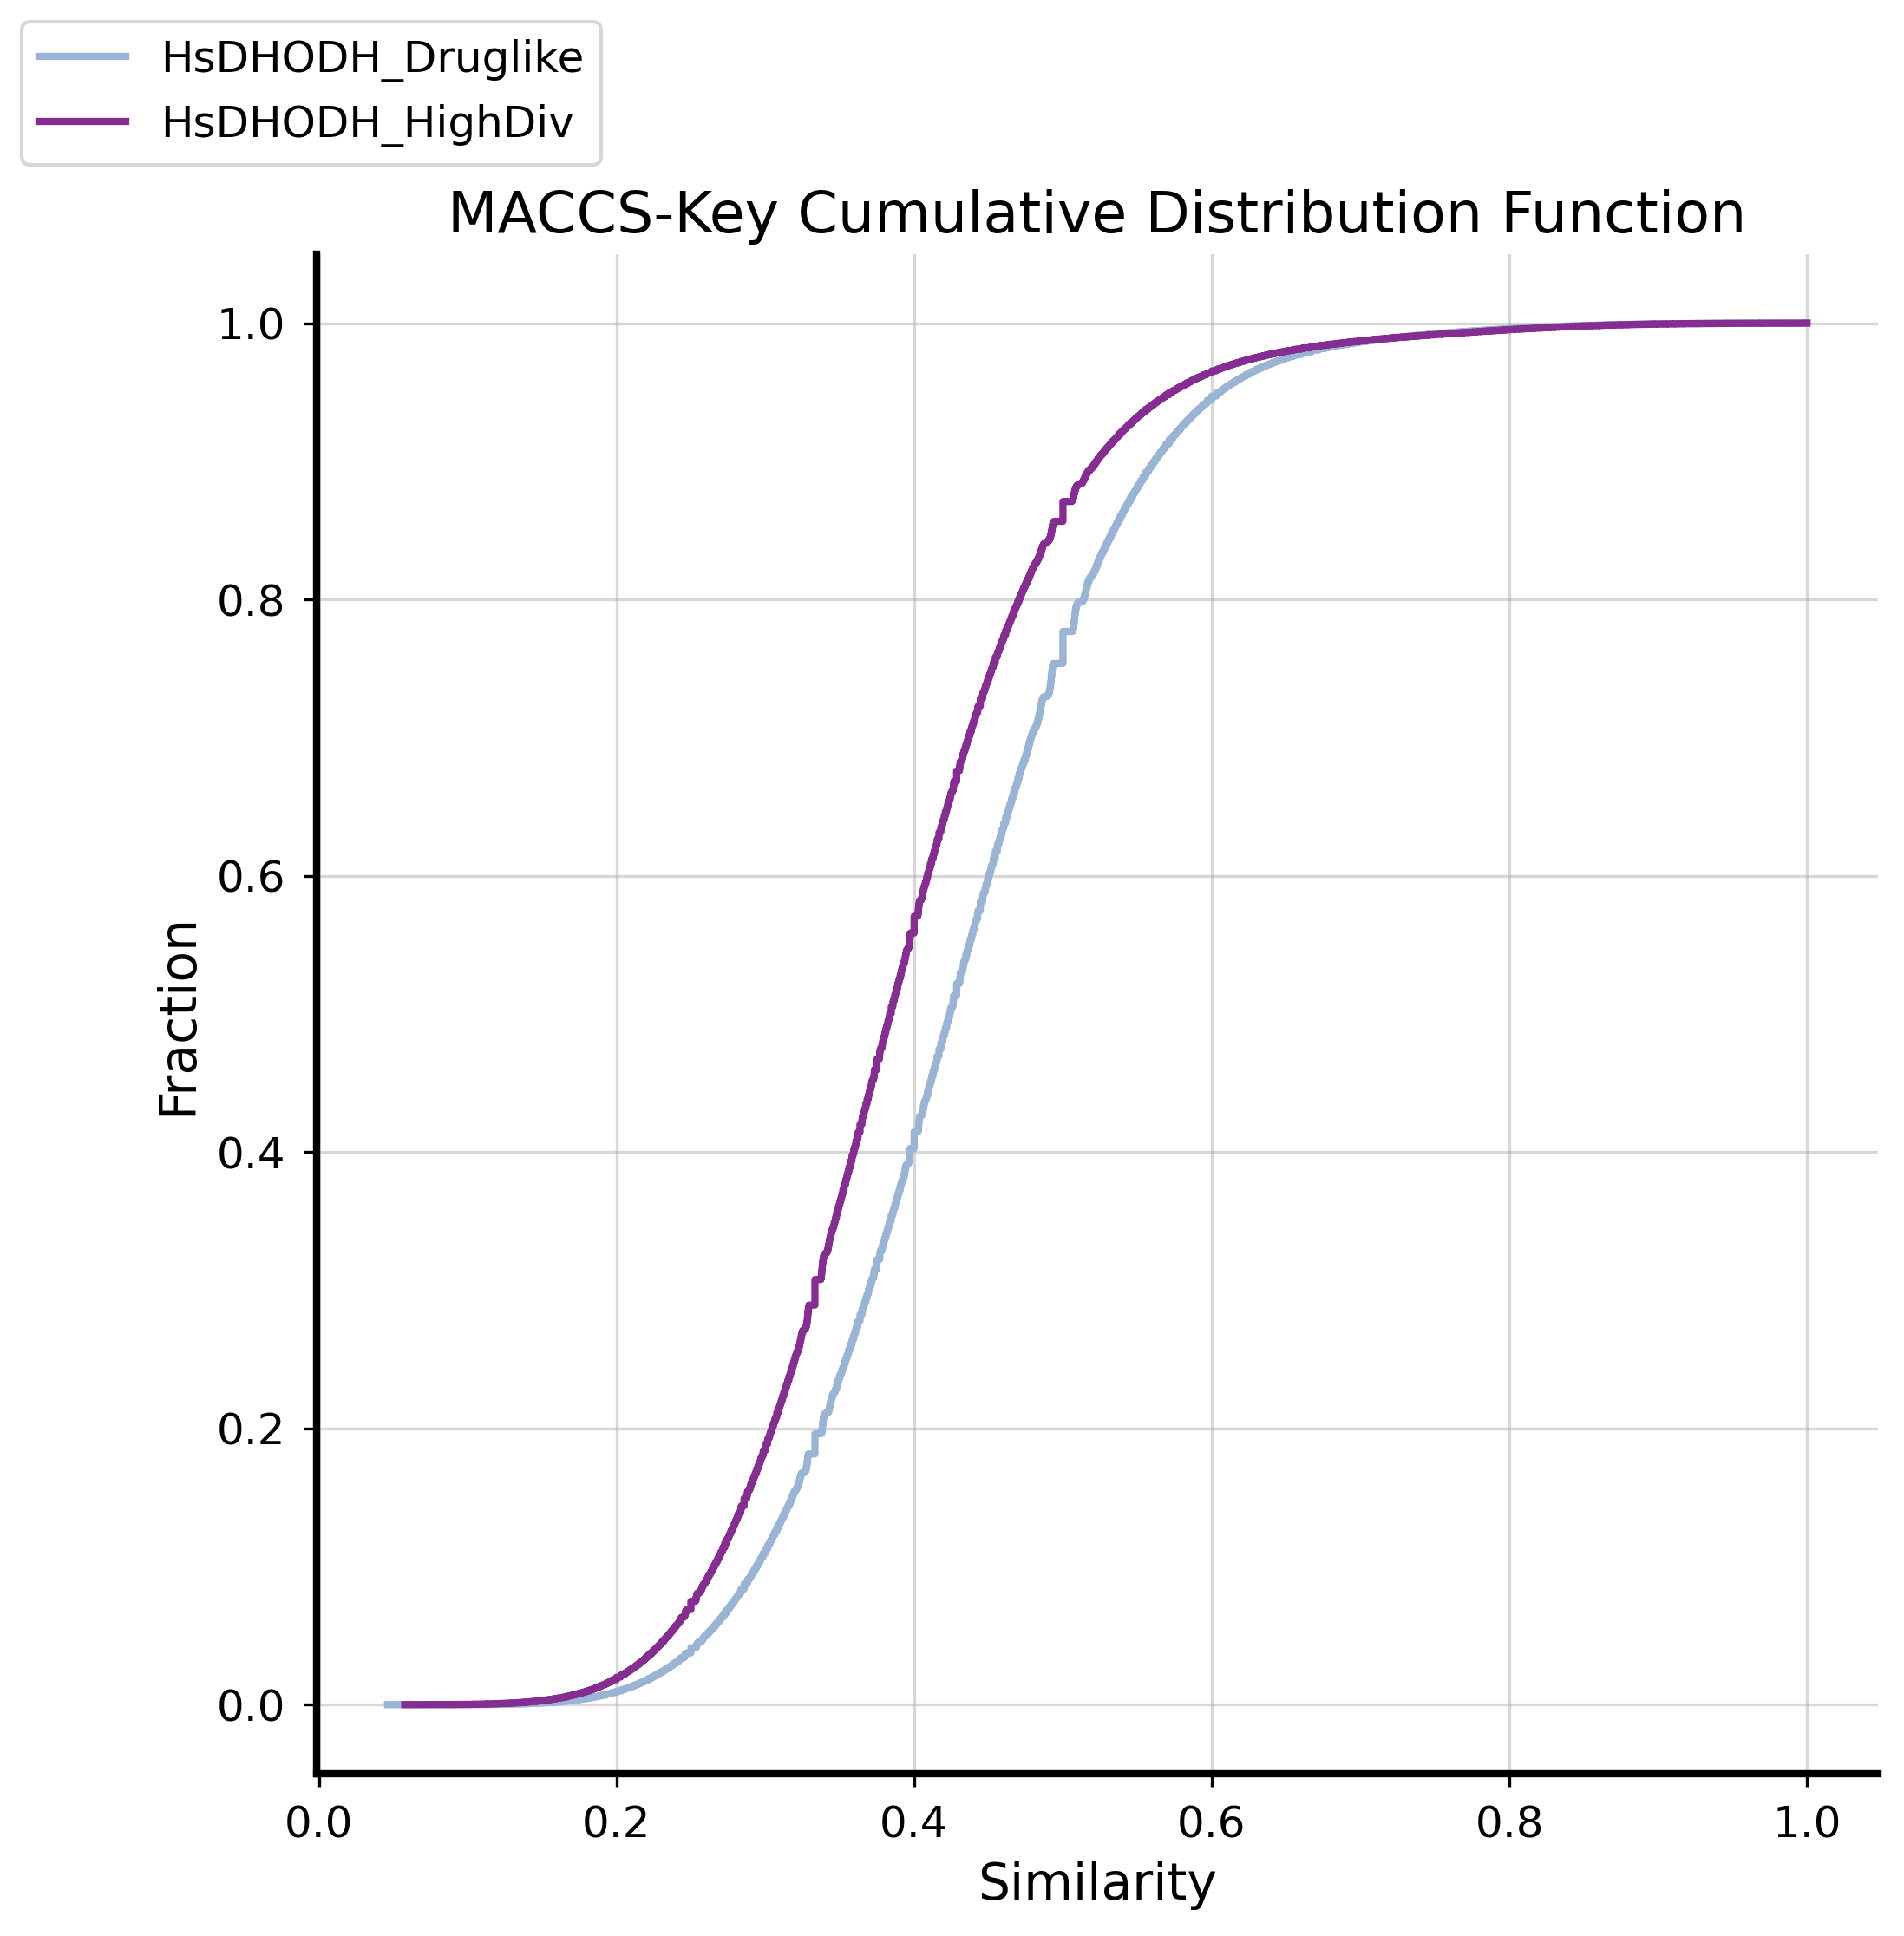

In [ ]:
# MACCS fingerprints + CDF
SimMatMACCS_druglike = np.sort(MACCSkeys_fp(smi_druglike))
SimMatMACCS_highdiv = np.sort(MACCSkeys_fp(smi_highdiv))

proportionMACCS_druglike = np.arange(len(SimMatMACCS_druglike)) / (len(SimMatMACCS_druglike) - 1) if len(SimMatMACCS_druglike) > 1 else np.array([])
proportionMACCS_highdiv = np.arange(len(SimMatMACCS_highdiv)) / (len(SimMatMACCS_highdiv) - 1) if len(SimMatMACCS_highdiv) > 1 else np.array([])

_bupu = sns.color_palette("BuPu", 4)
fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(1, 1, 1)
ax.plot(SimMatMACCS_druglike, proportionMACCS_druglike, label="HsDHODH_Druglike", c=_bupu[1], linewidth=2)
ax.plot(SimMatMACCS_highdiv, proportionMACCS_highdiv, label="HsDHODH_HighDiv", c=_bupu[3], linewidth=2)
ax.grid(alpha=0.5)
ax.set_xlabel("Similarity", fontsize=14)
ax.set_ylabel("Fraction", fontsize=14)
ax.set_title("MACCS-Key Cumulative Distribution Function", fontsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2.0)
ax.spines["bottom"].set_linewidth(2.0)
ax.tick_params(axis="both", which="major", pad=5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
fig.legend(loc="upper left", fontsize=12, frameon=True)
fig.subplots_adjust(left=0.15, bottom=0.15)
plt.savefig(RESULTS_DIR / "MACCS_CDF.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# MACCS statistics
MACCS_druglike_df = pd.DataFrame(SimMatMACCS_druglike, columns=["MACCS_HsDHODH_Druglike"])
MACCS_highdiv_df = pd.DataFrame(SimMatMACCS_highdiv, columns=["MACCS_HsDHODH_HighDiv"])
MACCS_stats = pd.concat([
    MACCS_druglike_df.describe().round(3),
    MACCS_highdiv_df.describe().round(3)
], axis=1)
MACCS_stats.to_csv(RESULTS_DIR / "MACCS_Statistics.csv")
MACCS_stats

,MACCS_HsDHODH_Druglike,MACCS_HsDHODH_HighDiv
count,2158003.000,2708628.000
mean,0.428,0.392
std,0.108,0.107
min,0.046,0.058
25%,0.354,0.320
50%,0.424,0.384
75%,0.493,0.452
max,1.000,1.000


In [ ]:
# ECFP4 fingerprints + CDF
SimMatECFP4_druglike = np.sort(ECFP(smi_druglike, 2))
SimMatECFP4_highdiv = np.sort(ECFP(smi_highdiv, 2))

proportionECFP4_druglike = np.arange(len(SimMatECFP4_druglike)) / (len(SimMatECFP4_druglike) - 1) if len(SimMatECFP4_druglike) > 1 else np.array([])
proportionECFP4_highdiv = np.arange(len(SimMatECFP4_highdiv)) / (len(SimMatECFP4_highdiv) - 1) if len(SimMatECFP4_highdiv) > 1 else np.array([])

_bupu = sns.color_palette("BuPu", 4)
fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(1, 1, 1)
ax.plot(SimMatECFP4_druglike, proportionECFP4_druglike, label="HsDHODH_Druglike", c=_bupu[1], linewidth=2)
ax.plot(SimMatECFP4_highdiv, proportionECFP4_highdiv, label="HsDHODH_HighDiv", c=_bupu[3], linewidth=2)
ax.grid(alpha=0.5)
ax.set_xlabel("Similarity", fontsize=14)
ax.set_ylabel("Fraction", fontsize=14)
ax.set_title("ECFP4 Cumulative Distribution Function", fontsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2.0)
ax.spines["bottom"].set_linewidth(2.0)
ax.tick_params(axis="both", which="major", pad=5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
fig.legend(loc="upper left", fontsize=12, frameon=True)
fig.subplots_adjust(left=0.15, bottom=0.15)
plt.savefig(RESULTS_DIR / "ECFP4_CDF.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# ECFP4 statistics
ECFP4_druglike_df = pd.DataFrame(SimMatECFP4_druglike, columns=["ECFP4_HsDHODH_Druglike"])
ECFP4_highdiv_df = pd.DataFrame(SimMatECFP4_highdiv, columns=["ECFP4_HsDHODH_HighDiv"])
ECFP4_stats = pd.concat([
    ECFP4_druglike_df.describe().round(3),
    ECFP4_highdiv_df.describe().round(3)
], axis=1)
ECFP4_stats.to_csv(RESULTS_DIR / "ECFP4_Statistics.csv")
ECFP4_stats

In [ ]:
# Molecular descriptor functions
def MW(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcExactMolWt(mol)

def HBA(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumHBA(mol)

def HBD(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumHBD(mol)

def LOG_P(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return Descriptors.MolLogP(mol)

def TPSA(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcTPSA(mol)

def RB(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumRotatableBonds(mol)

def NumCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")

def NumOxygens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return [atom.GetSymbol() for atom in mol.GetAtoms()].count("O")

def NumNitrogens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return [atom.GetSymbol() for atom in mol.GetAtoms()].count("N")

def FractionOfCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    heavy_atoms = mol.GetNumHeavyAtoms()
    return (carbons / heavy_atoms) if heavy_atoms > 0 else 0

def FractionOfOxygens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    oxygens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("O")
    heavy_atoms = mol.GetNumHeavyAtoms()
    return (oxygens / heavy_atoms) if heavy_atoms > 0 else 0

def FractionOfNitrogens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    nitrogens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("N")
    heavy_atoms = mol.GetNumHeavyAtoms()
    return (nitrogens / heavy_atoms) if heavy_atoms > 0 else 0

def CSP3(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcFractionCSP3(mol)

def FractionOfChiralCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    chiral_atoms = [x[0] for x in Chem.FindMolChiralCenters(mol, force=True, includeUnassigned=True)]
    chiral_carbons = [mol.GetAtomWithIdx(i).GetSymbol() for i in chiral_atoms].count("C")
    return (chiral_carbons / carbons) if carbons > 0 else 0

def NumHeavyAtoms(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return mol.GetNumHeavyAtoms()

def Ring(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumRings(mol)

def AliphaticRing(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAliphaticRings(mol)

def AromaticRing(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAromaticRings(mol)

def Heterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumHeterocycles(mol)

def AliphaticHeterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAliphaticHeterocycles(mol)

def AromaticHeterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAromaticHeterocycles(mol)

def SpiroAtom(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumSpiroAtoms(mol)

def BridgeheadAtom(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumBridgeheadAtoms(mol)

In [ ]:
# Calculate molecular descriptors
df_complete["MW"] = df_complete["SMILES"].apply(MW)
df_complete["HBA"] = df_complete["SMILES"].apply(HBA)
df_complete["HBD"] = df_complete["SMILES"].apply(HBD)
df_complete["LogP"] = df_complete["SMILES"].apply(LOG_P)
df_complete["TPSA"] = df_complete["SMILES"].apply(TPSA)
df_complete["RotBonds"] = df_complete["SMILES"].apply(RB)
df_complete["NumCarbons"] = df_complete["SMILES"].apply(NumCarbons)
df_complete["NumOxygens"] = df_complete["SMILES"].apply(NumOxygens)
df_complete["NumNitrogens"] = df_complete["SMILES"].apply(NumNitrogens)
df_complete["FractionCarbons"] = df_complete["SMILES"].apply(FractionOfCarbons)
df_complete["FractionOxygens"] = df_complete["SMILES"].apply(FractionOfOxygens)
df_complete["FractionNitrogens"] = df_complete["SMILES"].apply(FractionOfNitrogens)
df_complete["CSP3"] = df_complete["SMILES"].apply(CSP3)
df_complete["ChiralCarbonFraction"] = df_complete["SMILES"].apply(FractionOfChiralCarbons)
df_complete["HeavyAtoms"] = df_complete["SMILES"].apply(NumHeavyAtoms)
df_complete["NumRings"] = df_complete["SMILES"].apply(Ring)
df_complete["AliphaticRings"] = df_complete["SMILES"].apply(AliphaticRing)
df_complete["AromaticRings"] = df_complete["SMILES"].apply(AromaticRing)
df_complete["Heterocycles"] = df_complete["SMILES"].apply(Heterocycle)
df_complete["AliphaticHeterocycles"] = df_complete["SMILES"].apply(AliphaticHeterocycle)
df_complete["AromaticHeterocycles"] = df_complete["SMILES"].apply(AromaticHeterocycle)
df_complete["SpiroAtoms"] = df_complete["SMILES"].apply(SpiroAtom)
df_complete["BridgeheadAtoms"] = df_complete["SMILES"].apply(BridgeheadAtom)

print("Descriptors calculated")

Descriptors calculated


In [ ]:
# Descriptor statistics
descriptor_cols = [
    "MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds",
    "NumCarbons", "NumOxygens", "NumNitrogens",
    "FractionCarbons", "FractionOxygens", "FractionNitrogens",
    "CSP3", "ChiralCarbonFraction", "HeavyAtoms", "NumRings",
    "AliphaticRings", "AromaticRings", "Heterocycles",
    "AliphaticHeterocycles", "AromaticHeterocycles",
    "SpiroAtoms", "BridgeheadAtoms"
 ]

descriptor_stats = df_complete.groupby("Database")[descriptor_cols].agg(["mean", "std", "min", "max"]).round(2)
descriptor_stats.to_csv(RESULTS_DIR / "Descriptor_Statistics.csv")
descriptor_stats.head()

MW                          HBA                 HBD  \
                    mean    std     min     max  mean   std min max  mean   
Database                                                                    
HsDHODH_Druglike  291.20  56.01  164.06  493.01  4.55  1.43   1  10  2.64   
HsDHODH_HighDiv   315.32  60.06  165.08  496.86  4.75  1.32   2  11  2.80   

                        ... AromaticHeterocycles     SpiroAtoms               \
                   std  ...                  min max       mean  std min max   
Database                ...                                                    
HsDHODH_Druglike  0.73  ...                    0   3        0.0  0.0   0   0   
HsDHODH_HighDiv   0.87  ...                    0   3        0.0  0.0   0   0   

                 BridgeheadAtoms               
                            mean  std min max  
Database                                       
HsDHODH_Druglike             0.0  0.0   0   0  
HsDHODH_HighDiv              0.0  0.0   0   0  

[2 rows x 92 columns]

/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

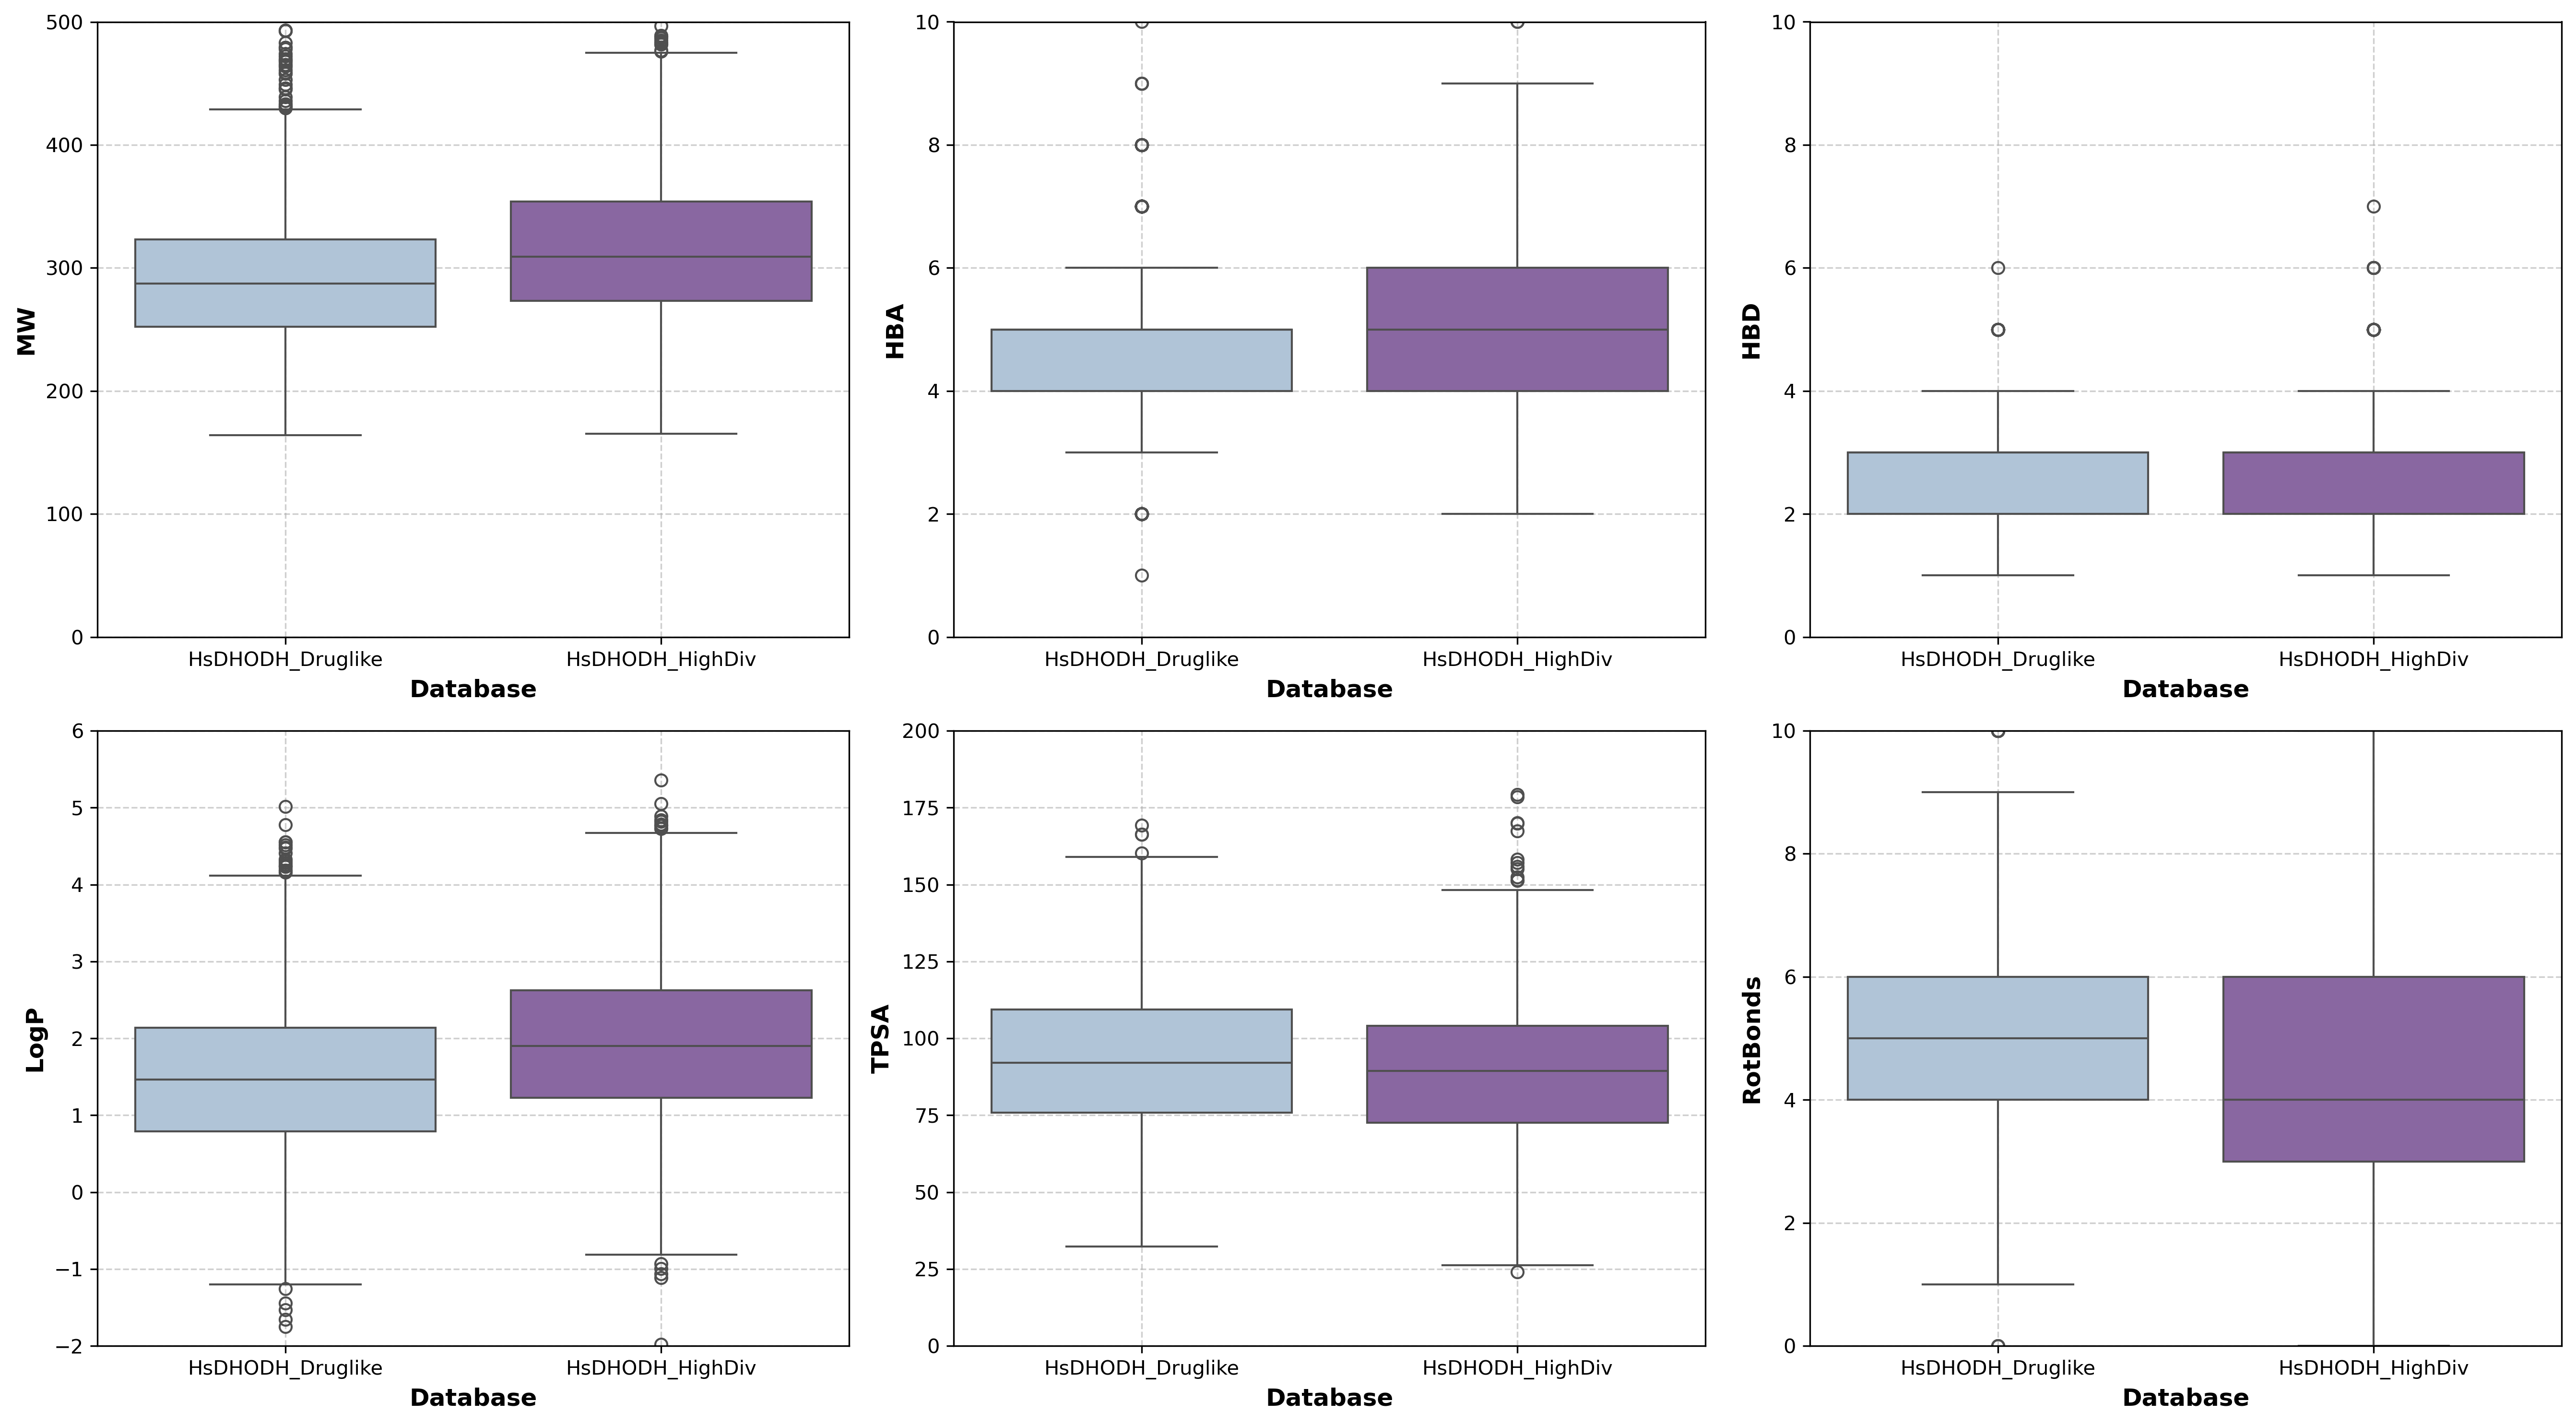

In [ ]:
# Boxplots of drug-like properties
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
variables = ["MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds"]
limits = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LogP": (-2, 6),
    "TPSA": (0, 200),
    "RotBonds": (0, 10)
}

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(
        x="Database",
        y=var,
        data=df_complete,
        order=ordre_desired,
        palette="BuPu",
        ax=ax
    )
    ax.set_xlabel("Database", fontsize=12, fontweight="bold")
    ax.set_ylabel(var, fontsize=12, fontweight="bold")
    if var in limits:
        ax.set_ylim(limits[var])
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Boxplots_Descriptors.png", dpi=600, bbox_inches="tight")
plt.show()

/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1376208341.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1376208341.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1376208341.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_50821/1376208341.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is dep

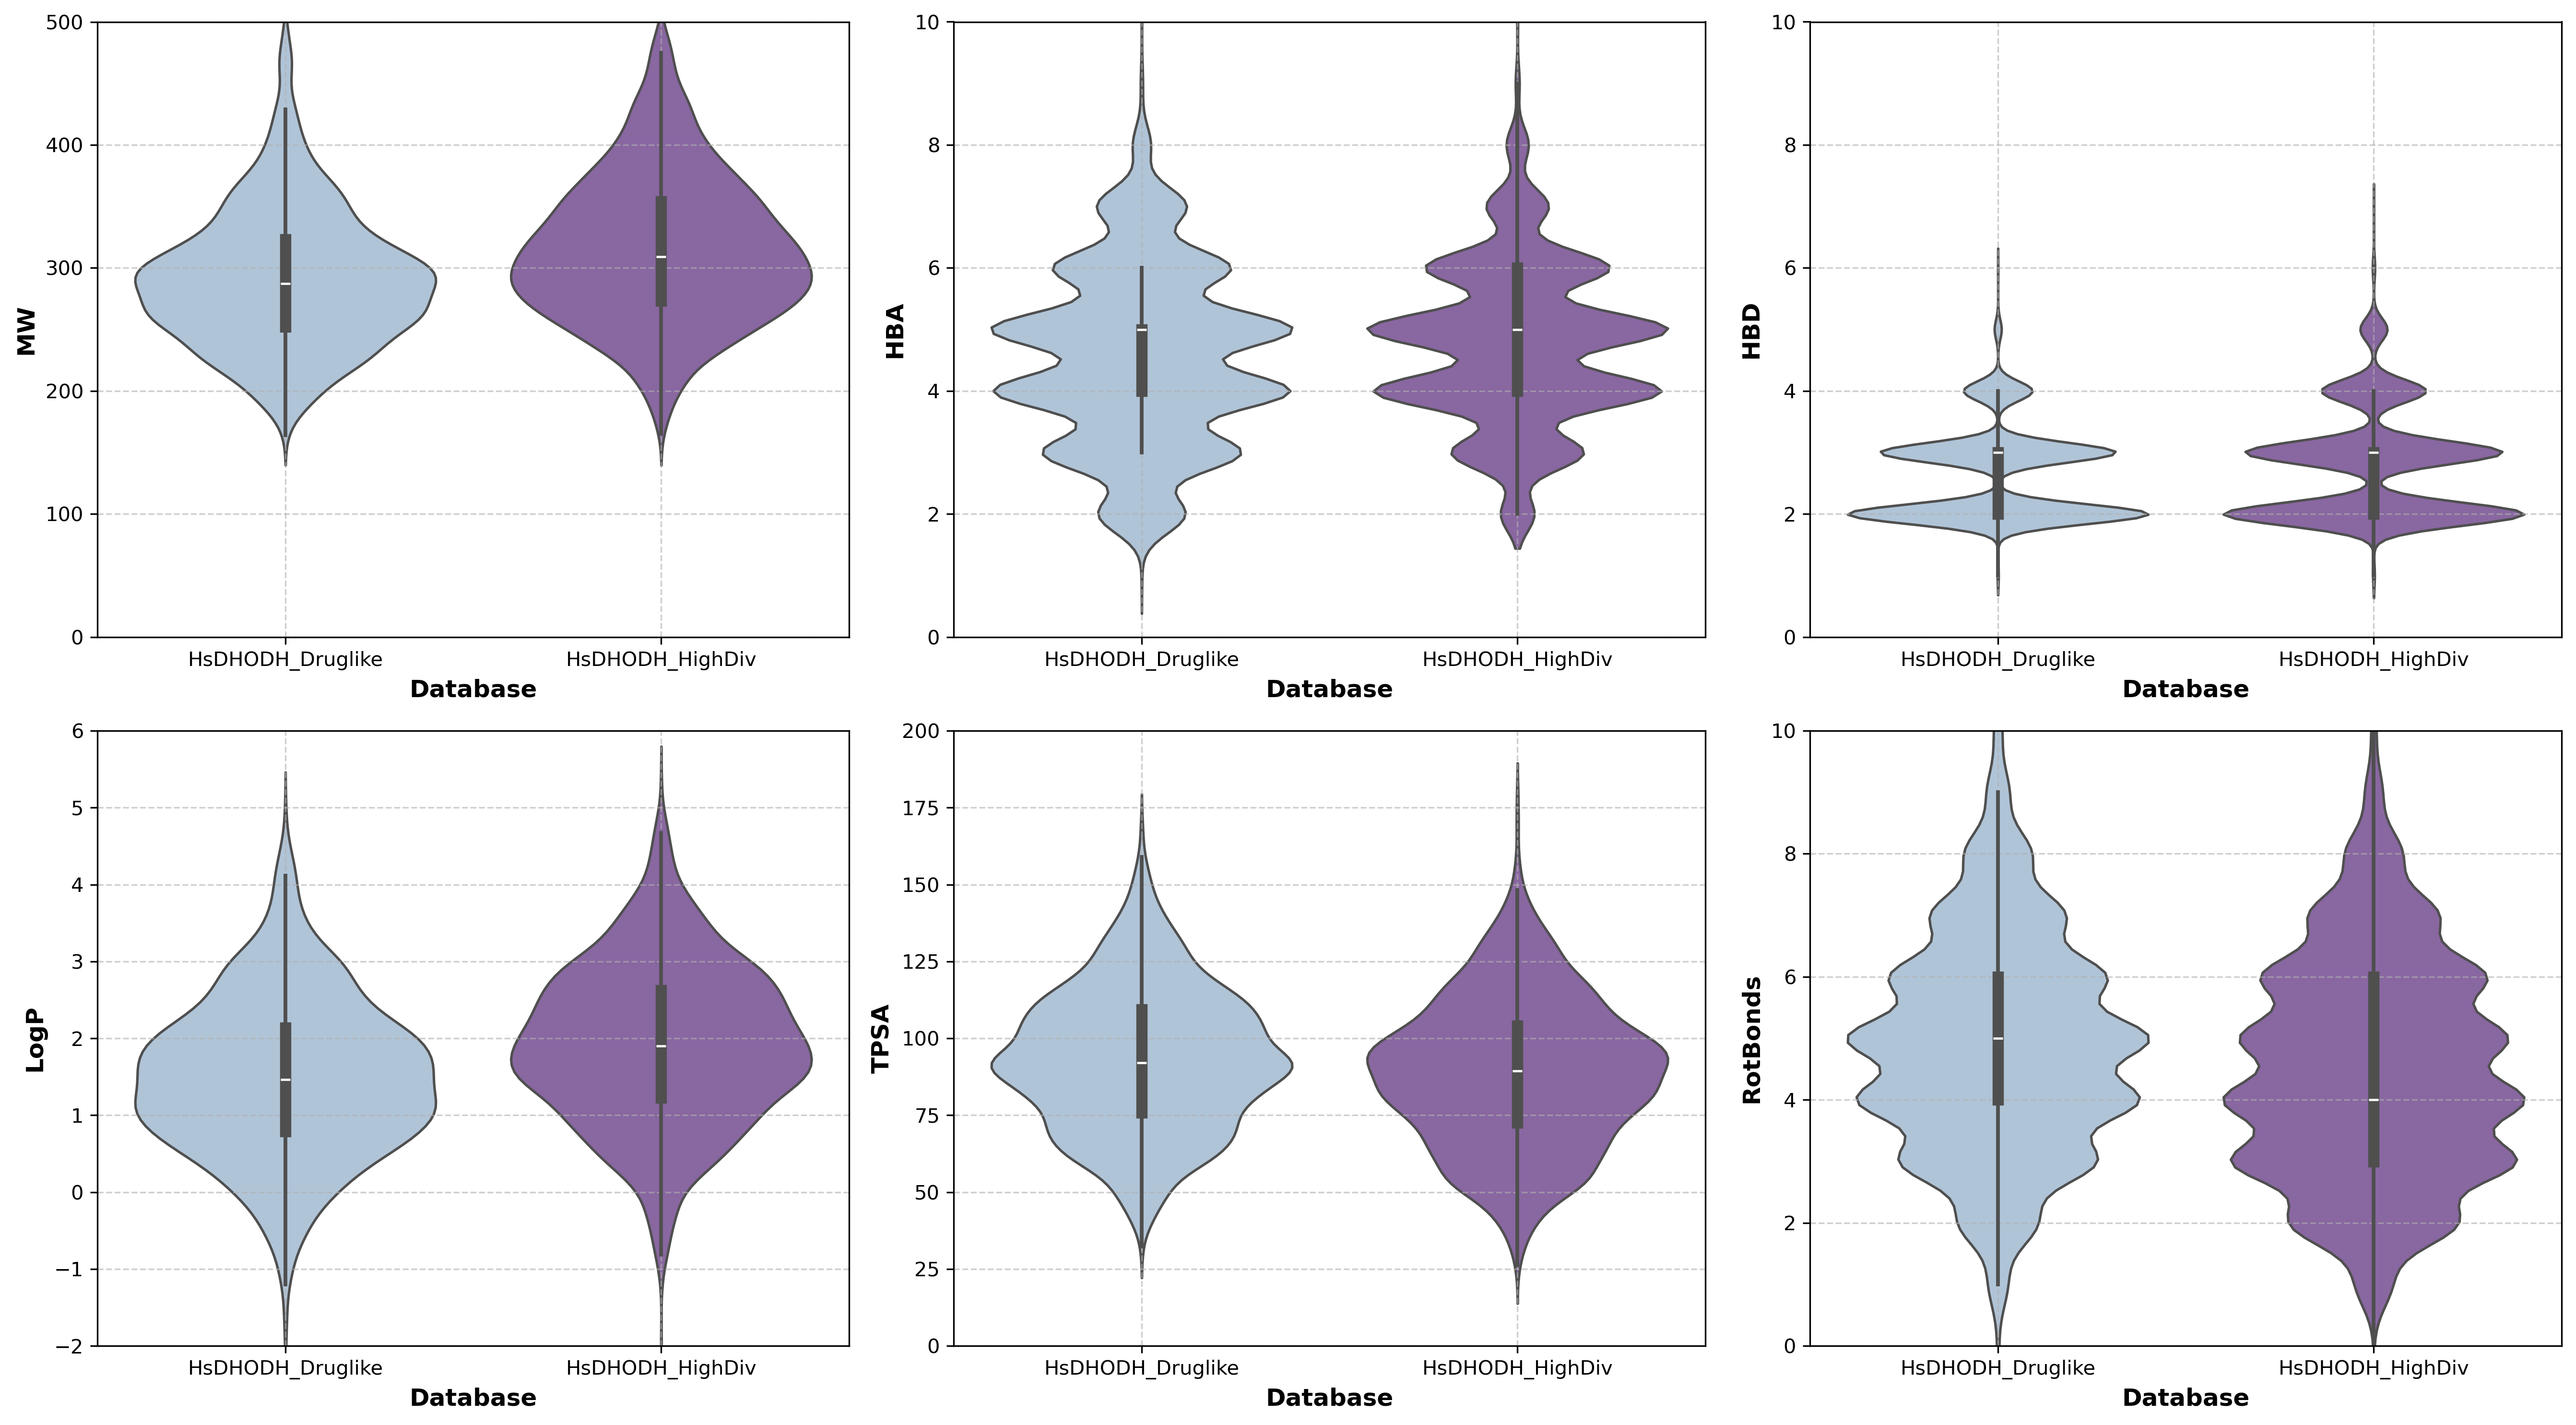

In [ ]:
# Violinplots of drug-like properties
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
variables = ["MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds"]
limits = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LogP": (-2, 6),
    "TPSA": (0, 200),
    "RotBonds": (0, 10)
}

for ax, var in zip(axes.flatten(), variables):
    sns.violinplot(
        x="Database",
        y=var,
        data=df_complete,
        order=ordre_desired,
        palette="BuPu",
        ax=ax
    )
    ax.set_xlabel("Database", fontsize=12, fontweight="bold")
    ax.set_ylabel(var, fontsize=12, fontweight="bold")
    if var in limits:
        ax.set_ylim(limits[var])
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Violinplots_Descriptors.png", dpi=600, bbox_inches="tight")
plt.show()

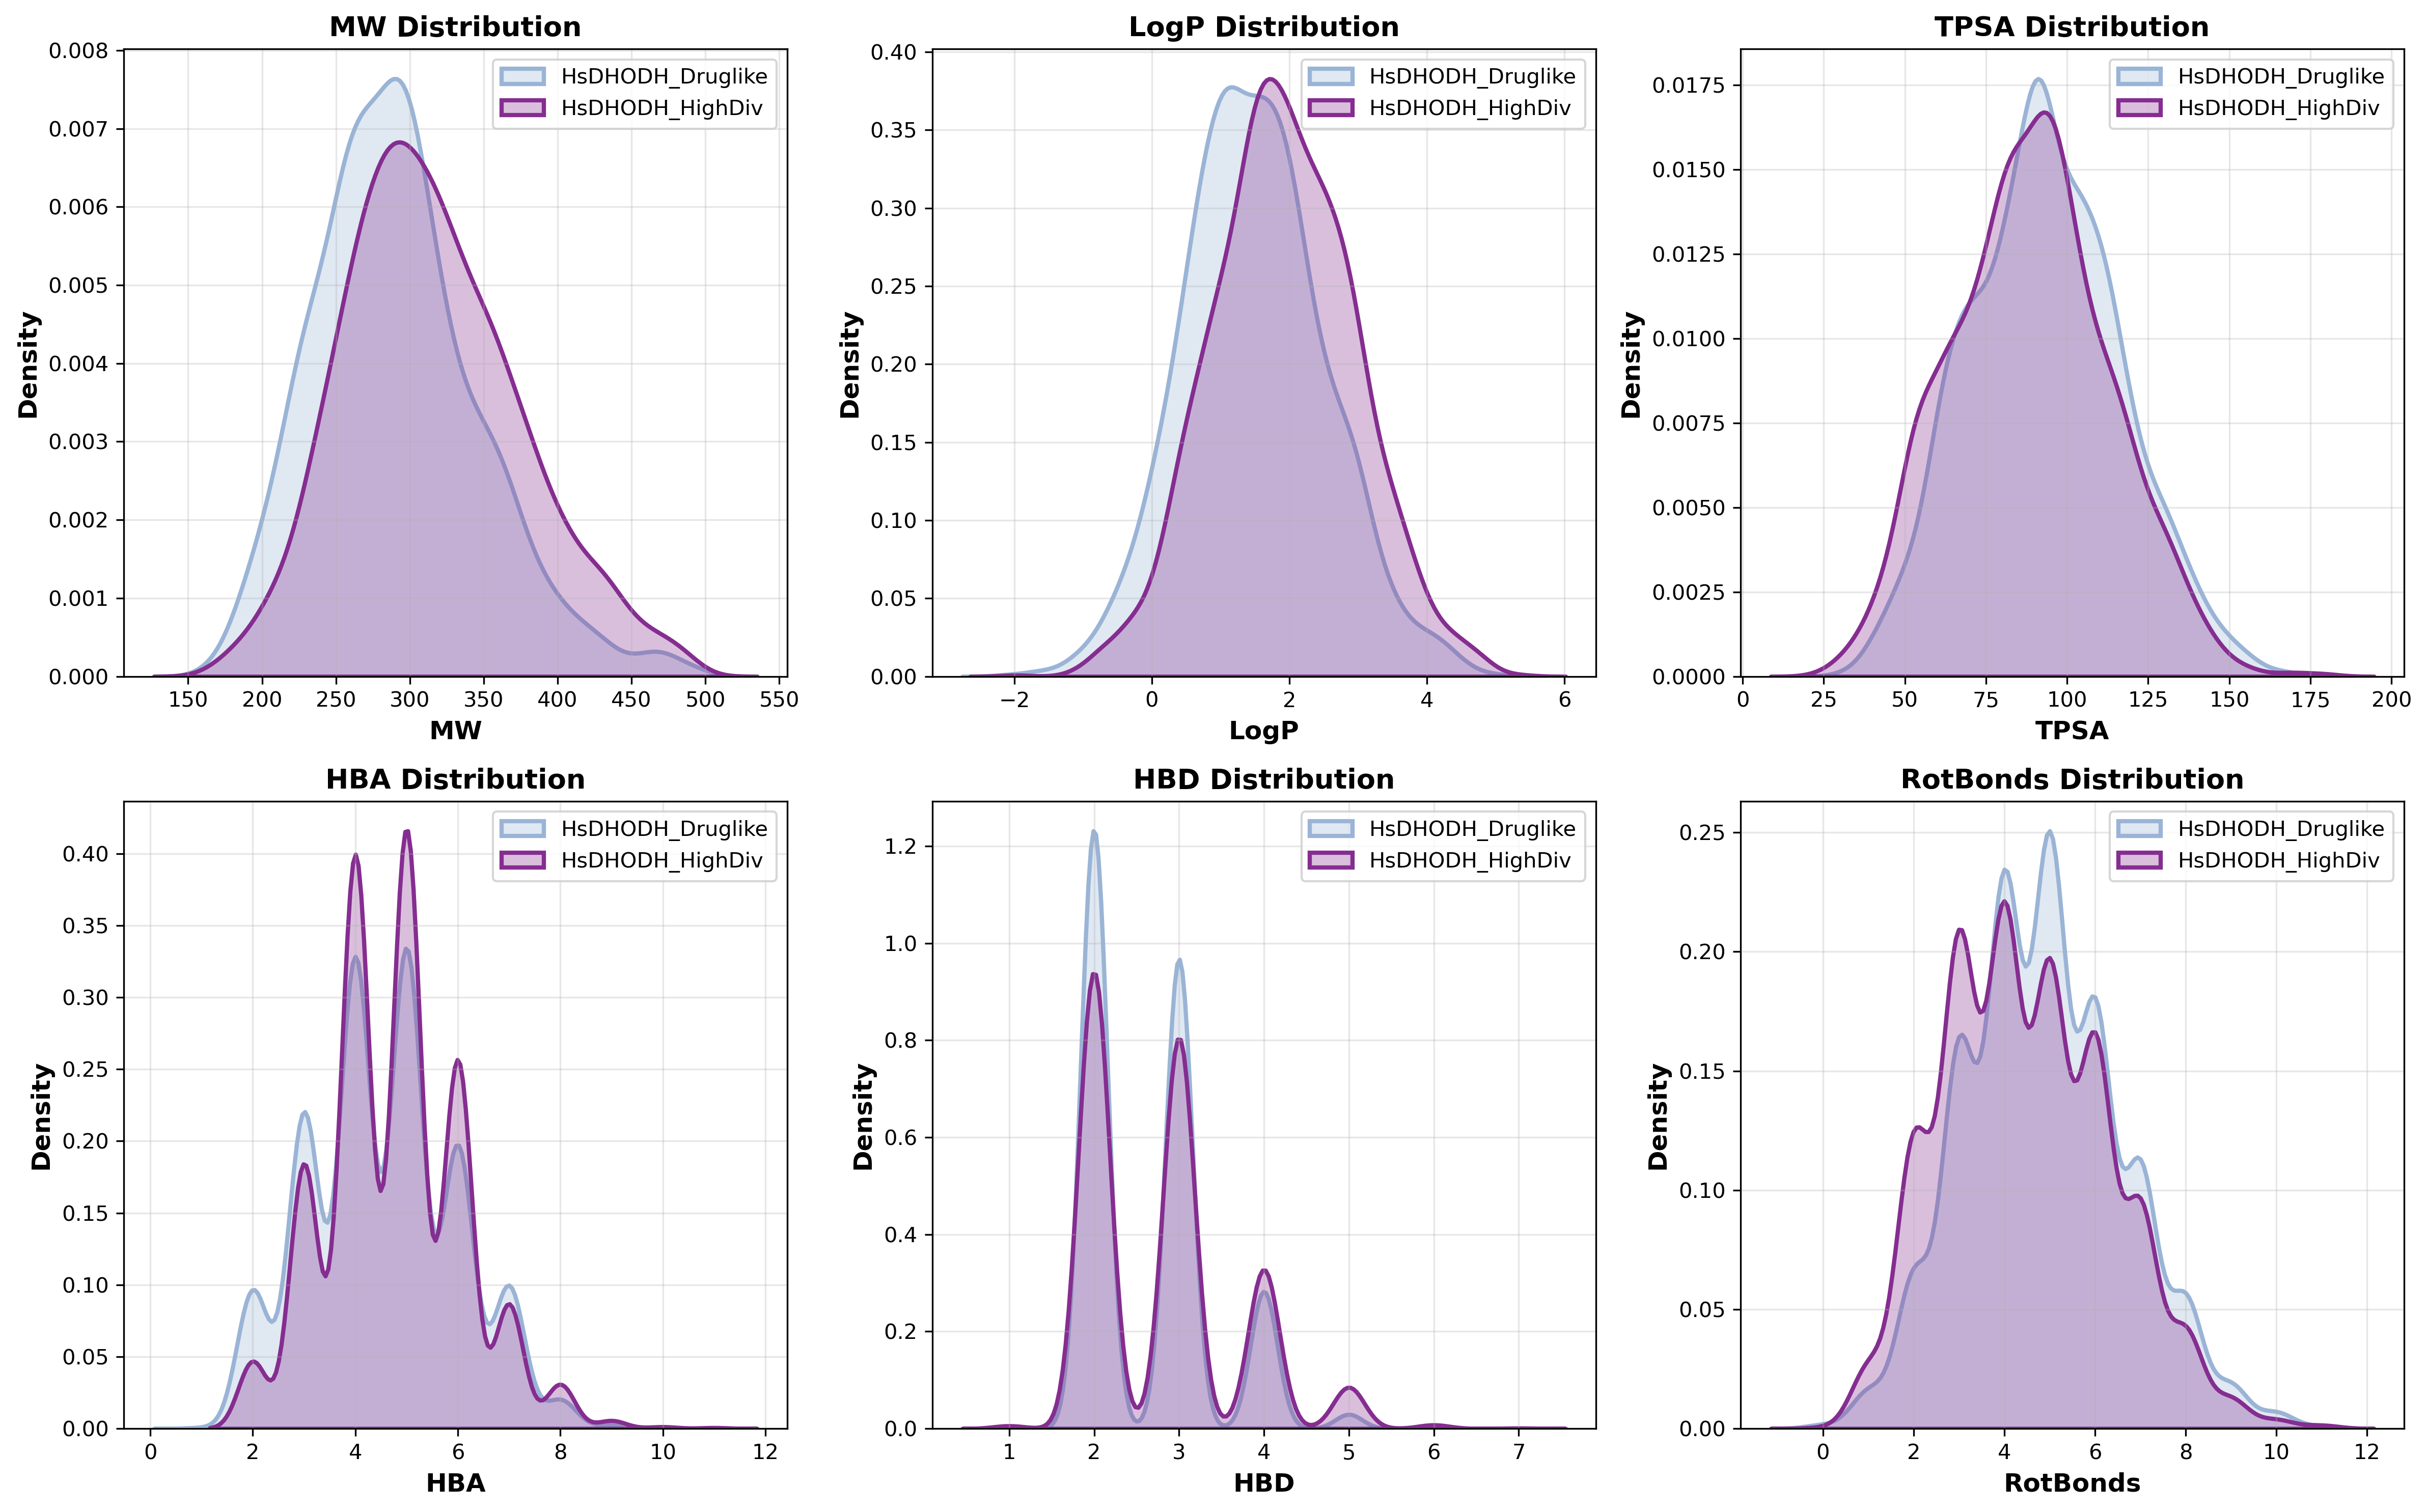

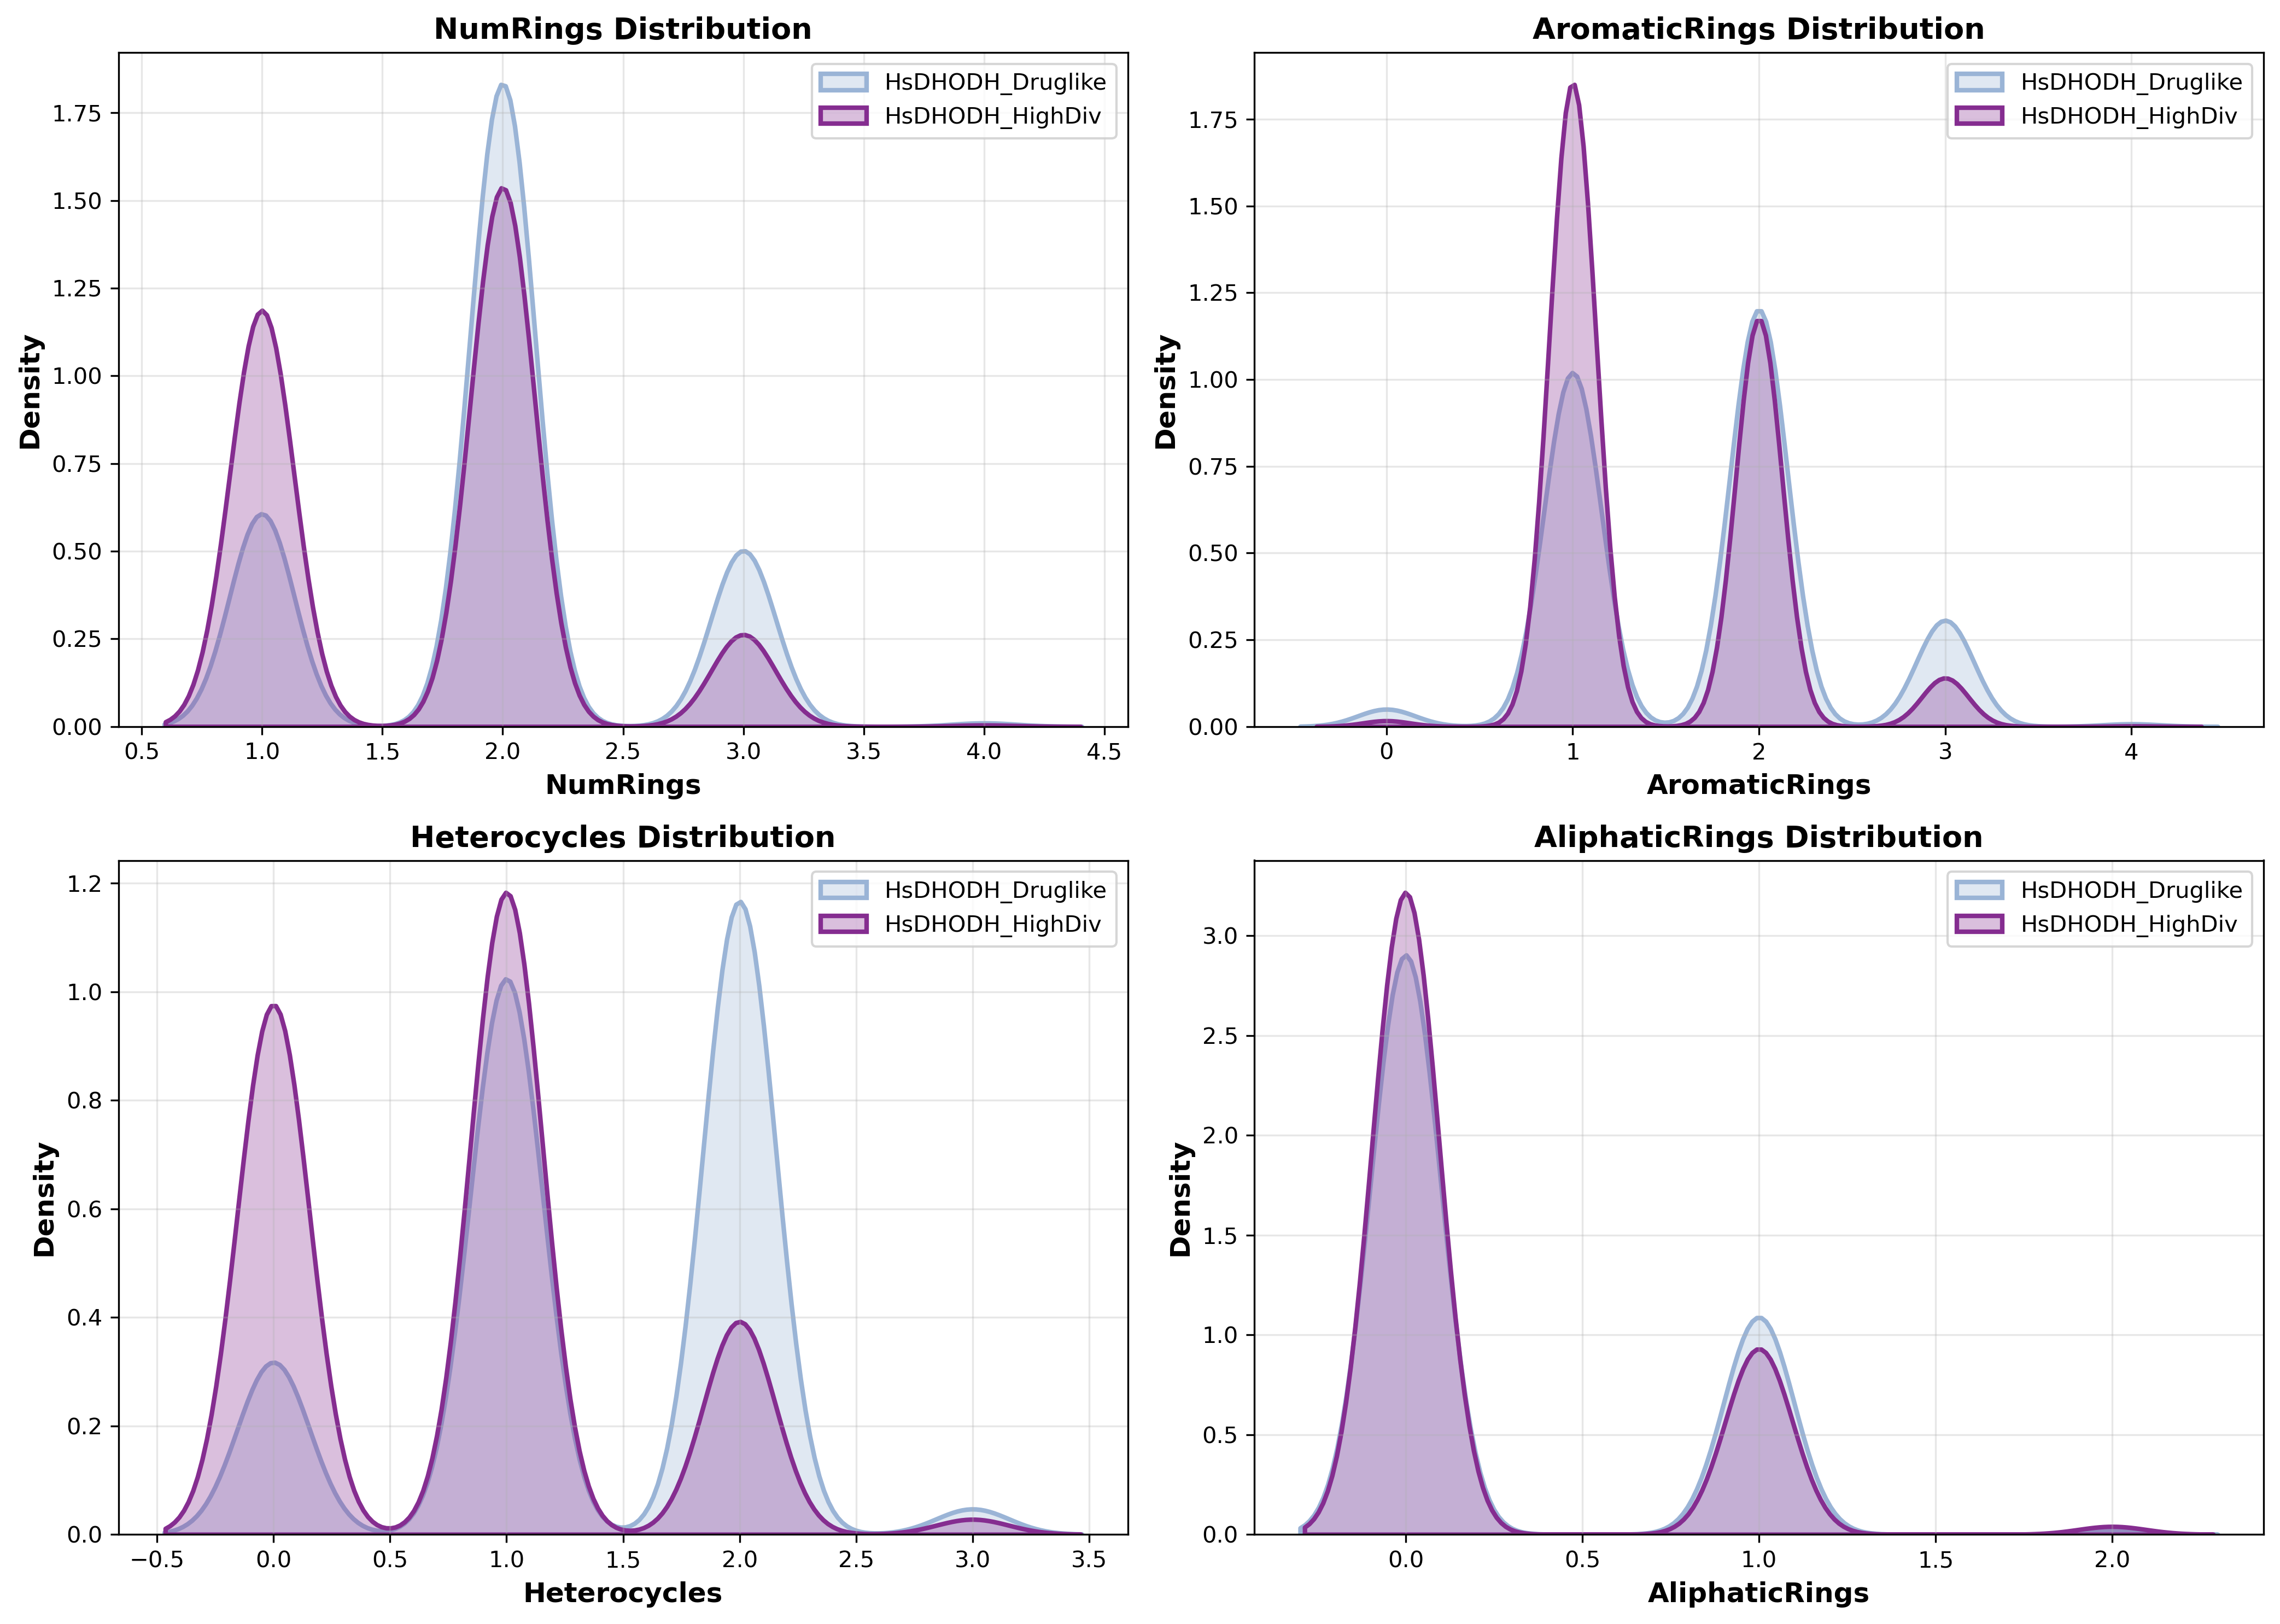

In [ ]:
# Distribution of key molecular properties
_bupu = sns.color_palette("BuPu", 4)
_colors = dict(zip(ordre_desired, [_bupu[1], _bupu[3]]))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)
properties = ["MW", "LogP", "TPSA", "HBA", "HBD", "RotBonds"]

for ax, prop in zip(axes.flatten(), properties):
    for db in ordre_desired:
        data = df_complete[df_complete["Database"] == db][prop].dropna()
        sns.kdeplot(data, ax=ax, label=db, color=_colors[db], linewidth=2, fill=True, alpha=0.3)
    ax.set_xlabel(prop, fontsize=12, fontweight="bold")
    ax.set_ylabel("Density", fontsize=12, fontweight="bold")
    ax.set_title(f"{prop} Distribution", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Distributions_MolecularProperties.png", dpi=600, bbox_inches="tight")
plt.show()

# Distribution of ring systems
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
ring_properties = ["NumRings", "AromaticRings", "Heterocycles", "AliphaticRings"]

for ax, prop in zip(axes.flatten(), ring_properties):
    for db in ordre_desired:
        data = df_complete[df_complete["Database"] == db][prop].dropna()
        sns.kdeplot(data, ax=ax, label=db, color=_colors[db], linewidth=2, fill=True, alpha=0.3)
    ax.set_xlabel(prop, fontsize=12, fontweight="bold")
    ax.set_ylabel("Density", fontsize=12, fontweight="bold")
    ax.set_title(f"{prop} Distribution", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Distributions_RingSystems.png", dpi=600, bbox_inches="tight")
plt.show()

## 3. Additional Physicochemical Plots

In [ ]:
# Comparison of CSP3 and chiral carbon fraction
fig = plt.figure(figsize=(10, 6), dpi=300)
descriptor_means = df_complete.groupby("Database")[["CSP3", "ChiralCarbonFraction"]].mean()

selected_properties = ["CSP3", "ChiralCarbonFraction"]
property_names = ["Fraction of Csp3", "Fraction of Chiral Carbons"]
_bupu = sns.color_palette("BuPu", 4)
colors = [_bupu[1], _bupu[3]]

databases = descriptor_means.index.tolist()
pos_x = np.arange(len(selected_properties))
width = 0.3

for i, db in enumerate(databases):
    values = [descriptor_means.loc[db, prop] for prop in selected_properties]
    bars = plt.bar(pos_x + i * width, values, width, label=db, color=colors[i],
                   alpha=0.8, edgecolor="black", linewidth=0.5)
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.xticks(pos_x + width / 2, property_names, fontsize=12)
plt.ylabel("Mean Value", fontsize=12, fontweight="bold")
plt.title("Comparison of CSP3 and Chiral Carbon Fraction", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, axis="y", alpha=0.3)
plt.margins(y=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "CSP3_ChiralCarbon_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Comparison of element fractions
fig = plt.figure(figsize=(10, 6), dpi=300)
descriptor_means = df_complete.groupby("Database")[["FractionCarbons", "FractionOxygens", "FractionNitrogens"]].mean()

selected_properties = ["FractionCarbons", "FractionOxygens", "FractionNitrogens"]
property_names = ["Fraction of Carbons", "Fraction of Oxygens", "Fraction of Nitrogens"]
_bupu = sns.color_palette("BuPu", 4)
colors = [_bupu[1], _bupu[3]]

databases = descriptor_means.index.tolist()
pos_x = np.arange(len(selected_properties))
width = 0.3

for i, db in enumerate(databases):
    values = [descriptor_means.loc[db, prop] for prop in selected_properties]
    bars = plt.bar(pos_x + i * width, values, width, label=db, color=colors[i],
                   alpha=0.8, edgecolor="black", linewidth=0.5)
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.xticks(pos_x + width / 2, property_names, fontsize=12)
plt.ylabel("Mean Value", fontsize=12, fontweight="bold")
plt.title("Comparison of Element Fractions", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, axis="y", alpha=0.3)
plt.margins(y=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ElementFractions_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Save full table with all descriptors
df_complete.to_csv(RESULTS_DIR / "Complete_Dataset_With_Descriptors.csv", index=False)

saved_outputs = [
    "MACCS_CDF.png",
    "ECFP4_CDF.png",
    "Boxplots_Descriptors.png",
    "Violinplots_Descriptors.png",
    "CSP3_ChiralCarbon_Comparison.png",
    "ElementFractions_Comparison.png",
    "Distributions_MolecularProperties.png",
    "Distributions_RingSystems.png",
    "MACCS_Statistics.csv",
    "ECFP4_Statistics.csv",
    "Descriptor_Statistics.csv",
    "Complete_Dataset_With_Descriptors.csv",
]

print(f"Saved {len(saved_outputs)} files in: {RESULTS_DIR}")

## 4. Export Summary

In [ ]:
# Quick check of generated files
for name in saved_outputs:
    path = RESULTS_DIR / name
    print(f"[OK] {name}" if path.exists() else f"[MISSING] {name}")

[OK] MACCS_CDF.png
[OK] Morgan2_CDF.png
[OK] Boxplots_Descriptors.png
[OK] Violinplots_Descriptors.png
[OK] CSP3_ChiralCarbon_Comparison.png
[OK] ElementFractions_Comparison.png
[OK] Distributions_MolecularProperties.png
[OK] Distributions_RingSystems.png
[OK] MACCS_Statistics.csv
[OK] Morgan2_Statistics.csv
[OK] Descriptor_Statistics.csv
[OK] Complete_Dataset_With_Descriptors.csv


## 5. Per-Subset Analyses (grouped by "Dataset" column)

Replicates all analyses above, but now comparing the `CONCAT`, `CRAFT`, `LANA`, `MAY` subsets **within** each diversity type. Outputs go to the `DRUGLIKE/` and `HIGHDIVERSITY/` subfolders of `RESULTS_DIR`. Colors follow the chemical-space t-SNE palette (`chemical_space_tsne.ipynb`).

In [ ]:
# Per-subset configuration: colors mirror chemical_space_tsne.ipynb
SUBSET_NAMES = ["CONCAT", "CRAFT", "LANA", "MAY"]
SUBSET_COLORS = {
    "CONCAT": "#e74c3c",  # red
    "CRAFT":  "#3498db",  # blue
    "LANA":   "#2ecc71",  # green
    "MAY":    "#f39c12",  # orange
}

RESULTS_DRUGLIKE = RESULTS_DIR / "DRUGLIKE"
RESULTS_HIGHDIV  = RESULTS_DIR / "HIGHDIVERSITY"
RESULTS_DRUGLIKE.mkdir(parents=True, exist_ok=True)
RESULTS_HIGHDIV.mkdir(parents=True, exist_ok=True)

DIVERSITY_CONFIGS = [
    {
        "name": "DRUGLIKE",
        "df": df_druglike,
        "subset_labels": [f"DRUGLIKE_{s}" for s in SUBSET_NAMES],
        "output_dir": RESULTS_DRUGLIKE,
    },
    {
        "name": "HIGHDIVERSITY",
        "df": df_highdiv,
        "subset_labels": [f"HIGHDIVERSITY_{s}" for s in SUBSET_NAMES],
        "output_dir": RESULTS_HIGHDIV,
    },
]

for cfg in DIVERSITY_CONFIGS:
    counts = cfg["df"]["Dataset"].value_counts().reindex(cfg["subset_labels"]).fillna(0).astype(int)
    print(f"{cfg['name']} -> {cfg['output_dir']}")
    for label, n in counts.items():
        print(f"  {label}: {n}")

In [ ]:
# Per-subset MACCS CDF + statistics (one plot / CSV per diversity)
for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    df = cfg["df"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]

    sim_by_subset = {}
    for subset, label in zip(SUBSET_NAMES, subset_labels):
        smi = df.loc[df["Dataset"] == label, "SMILES"].dropna().tolist()
        sim_by_subset[subset] = np.sort(MACCSkeys_fp(smi)) if smi else np.array([])

    fig = plt.figure(figsize=(8, 8), dpi=300)
    ax = fig.add_subplot(1, 1, 1)
    for subset in SUBSET_NAMES:
        sim = sim_by_subset[subset]
        if len(sim) < 2:
            continue
        proportion = np.arange(len(sim)) / (len(sim) - 1)
        ax.plot(sim, proportion, label=subset, c=SUBSET_COLORS[subset], linewidth=2)
    ax.grid(alpha=0.5)
    ax.set_xlabel("Similarity", fontsize=14)
    ax.set_ylabel("Fraction", fontsize=14)
    ax.set_title(f"MACCS-Key CDF — {div_name}", fontsize=16)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(axis="both", which="major", pad=5)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    fig.legend(loc="upper left", fontsize=12, frameon=True)
    fig.subplots_adjust(left=0.15, bottom=0.15)
    plt.savefig(out_dir / "MACCS_CDF.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    stats_frames = [
        pd.DataFrame(sim_by_subset[s], columns=[f"MACCS_{label}"])
        for s, label in zip(SUBSET_NAMES, subset_labels)
        if len(sim_by_subset[s]) > 0
    ]
    if stats_frames:
        stats = pd.concat([f.describe().round(3) for f in stats_frames], axis=1)
        stats.to_csv(out_dir / "MACCS_Statistics.csv")
        print(f"[{div_name}] MACCS stats saved to {out_dir / 'MACCS_Statistics.csv'}")

In [ ]:
# Per-subset ECFP4 CDF + statistics
for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    df = cfg["df"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]

    sim_by_subset = {}
    for subset, label in zip(SUBSET_NAMES, subset_labels):
        smi = df.loc[df["Dataset"] == label, "SMILES"].dropna().tolist()
        sim_by_subset[subset] = np.sort(ECFP(smi, 2)) if smi else np.array([])

    fig = plt.figure(figsize=(8, 8), dpi=300)
    ax = fig.add_subplot(1, 1, 1)
    for subset in SUBSET_NAMES:
        sim = sim_by_subset[subset]
        if len(sim) < 2:
            continue
        proportion = np.arange(len(sim)) / (len(sim) - 1)
        ax.plot(sim, proportion, label=subset, c=SUBSET_COLORS[subset], linewidth=2)
    ax.grid(alpha=0.5)
    ax.set_xlabel("Similarity", fontsize=14)
    ax.set_ylabel("Fraction", fontsize=14)
    ax.set_title(f"ECFP4 CDF — {div_name}", fontsize=16)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(axis="both", which="major", pad=5)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    fig.legend(loc="upper left", fontsize=12, frameon=True)
    fig.subplots_adjust(left=0.15, bottom=0.15)
    plt.savefig(out_dir / "ECFP4_CDF.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    stats_frames = [
        pd.DataFrame(sim_by_subset[s], columns=[f"ECFP4_{label}"])
        for s, label in zip(SUBSET_NAMES, subset_labels)
        if len(sim_by_subset[s]) > 0
    ]
    if stats_frames:
        stats = pd.concat([f.describe().round(3) for f in stats_frames], axis=1)
        stats.to_csv(out_dir / "ECFP4_Statistics.csv")
        print(f"[{div_name}] ECFP4 stats saved to {out_dir / 'ECFP4_Statistics.csv'}")

In [ ]:
# Per-subset descriptor statistics (grouped by "Dataset")
for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]

    df_sub = df_complete[df_complete["Dataset"].isin(subset_labels)]
    stats = (
        df_sub.groupby("Dataset")[descriptor_cols]
        .agg(["mean", "std", "min", "max"])
        .round(2)
        .reindex(subset_labels)
    )
    stats.to_csv(out_dir / "Descriptor_Statistics.csv")
    print(f"[{div_name}] Descriptor stats saved to {out_dir / 'Descriptor_Statistics.csv'}")

In [ ]:
# Per-subset boxplots and violinplots of drug-like properties
_box_variables = ["MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds"]
_box_limits = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LogP": (-2, 6),
    "TPSA": (0, 200),
    "RotBonds": (0, 10),
}

for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]

    df_sub = df_complete[df_complete["Dataset"].isin(subset_labels)].copy()
    palette = {label: SUBSET_COLORS[s] for s, label in zip(SUBSET_NAMES, subset_labels)}

    # Boxplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
    for ax, var in zip(axes.flatten(), _box_variables):
        sns.boxplot(
            x="Dataset",
            y=var,
            data=df_sub,
            order=subset_labels,
            palette=palette,
            ax=ax,
        )
        ax.set_xticklabels(SUBSET_NAMES, rotation=0)
        ax.set_xlabel("Dataset", fontsize=12, fontweight="bold")
        ax.set_ylabel(var, fontsize=12, fontweight="bold")
        if var in _box_limits:
            ax.set_ylim(_box_limits[var])
        ax.grid(True, linestyle="--", alpha=0.6)
    fig.suptitle(f"Boxplots — {div_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_dir / "Boxplots_Descriptors.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Violinplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
    for ax, var in zip(axes.flatten(), _box_variables):
        sns.violinplot(
            x="Dataset",
            y=var,
            data=df_sub,
            order=subset_labels,
            palette=palette,
            ax=ax,
        )
        ax.set_xticklabels(SUBSET_NAMES, rotation=0)
        ax.set_xlabel("Dataset", fontsize=12, fontweight="bold")
        ax.set_ylabel(var, fontsize=12, fontweight="bold")
        if var in _box_limits:
            ax.set_ylim(_box_limits[var])
        ax.grid(True, linestyle="--", alpha=0.6)
    fig.suptitle(f"Violinplots — {div_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_dir / "Violinplots_Descriptors.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"[{div_name}] Boxplots + violinplots saved")

In [ ]:
# Per-subset KDE distributions: molecular properties + ring systems
_kde_props = ["MW", "LogP", "TPSA", "HBA", "HBD", "RotBonds"]
_kde_rings = ["NumRings", "AromaticRings", "Heterocycles", "AliphaticRings"]

for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]

    # Molecular properties
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)
    for ax, prop in zip(axes.flatten(), _kde_props):
        for subset, label in zip(SUBSET_NAMES, subset_labels):
            data = df_complete.loc[df_complete["Dataset"] == label, prop].dropna()
            if data.empty:
                continue
            sns.kdeplot(
                data, ax=ax, label=subset,
                color=SUBSET_COLORS[subset],
                linewidth=2, fill=True, alpha=0.3,
            )
        ax.set_xlabel(prop, fontsize=12, fontweight="bold")
        ax.set_ylabel("Density", fontsize=12, fontweight="bold")
        ax.set_title(f"{prop} Distribution", fontsize=13, fontweight="bold")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"Molecular Property Distributions — {div_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_dir / "Distributions_MolecularProperties.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Ring systems
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
    for ax, prop in zip(axes.flatten(), _kde_rings):
        for subset, label in zip(SUBSET_NAMES, subset_labels):
            data = df_complete.loc[df_complete["Dataset"] == label, prop].dropna()
            if data.empty:
                continue
            sns.kdeplot(
                data, ax=ax, label=subset,
                color=SUBSET_COLORS[subset],
                linewidth=2, fill=True, alpha=0.3,
            )
        ax.set_xlabel(prop, fontsize=12, fontweight="bold")
        ax.set_ylabel("Density", fontsize=12, fontweight="bold")
        ax.set_title(f"{prop} Distribution", fontsize=13, fontweight="bold")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"Ring System Distributions — {div_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_dir / "Distributions_RingSystems.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"[{div_name}] KDE distributions saved")

In [ ]:
# Per-subset CSP3 / chiral carbon and element-fraction grouped bar charts
def _grouped_bar(out_dir, div_name, subset_labels, descriptor_means,
                 selected_properties, property_names, title, filename):
    width = 0.2
    pos_x = np.arange(len(selected_properties))
    fig = plt.figure(figsize=(10, 6), dpi=300)
    for i, (subset, label) in enumerate(zip(SUBSET_NAMES, subset_labels)):
        if label not in descriptor_means.index:
            continue
        values = [descriptor_means.loc[label, prop] for prop in selected_properties]
        bars = plt.bar(
            pos_x + i * width, values, width,
            label=subset, color=SUBSET_COLORS[subset],
            alpha=0.85, edgecolor="black", linewidth=0.5,
        )
        for bar, value in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                bar.get_height() + 0.005,
                f"{value:.3f}",
                ha="center", va="bottom",
                fontsize=8, fontweight="bold",
            )
    plt.xticks(pos_x + width * 1.5, property_names, fontsize=12)
    plt.ylabel("Mean Value", fontsize=12, fontweight="bold")
    plt.title(f"{title} — {div_name}", fontsize=14, fontweight="bold")
    plt.legend(fontsize=11)
    plt.grid(True, axis="y", alpha=0.3)
    plt.margins(y=0.2)
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]
    df_sub = df_complete[df_complete["Dataset"].isin(subset_labels)]

    csp3_means = df_sub.groupby("Dataset")[["CSP3", "ChiralCarbonFraction"]].mean()
    _grouped_bar(
        out_dir, div_name, subset_labels, csp3_means,
        selected_properties=["CSP3", "ChiralCarbonFraction"],
        property_names=["Fraction of Csp3", "Fraction of Chiral Carbons"],
        title="CSP3 and Chiral Carbon Fraction",
        filename="CSP3_ChiralCarbon_Comparison.png",
    )

    elem_means = df_sub.groupby("Dataset")[["FractionCarbons", "FractionOxygens", "FractionNitrogens"]].mean()
    _grouped_bar(
        out_dir, div_name, subset_labels, elem_means,
        selected_properties=["FractionCarbons", "FractionOxygens", "FractionNitrogens"],
        property_names=["Fraction of Carbons", "Fraction of Oxygens", "Fraction of Nitrogens"],
        title="Element Fractions",
        filename="ElementFractions_Comparison.png",
    )

    print(f"[{div_name}] CSP3 + element-fraction bar charts saved")

In [ ]:
# Per-subset complete CSV + summary
per_subset_outputs = [
    "MACCS_CDF.png", "ECFP4_CDF.png",
    "Boxplots_Descriptors.png", "Violinplots_Descriptors.png",
    "CSP3_ChiralCarbon_Comparison.png", "ElementFractions_Comparison.png",
    "Distributions_MolecularProperties.png", "Distributions_RingSystems.png",
    "MACCS_Statistics.csv", "ECFP4_Statistics.csv",
    "Descriptor_Statistics.csv", "Complete_Dataset_With_Descriptors.csv",
]

for cfg in DIVERSITY_CONFIGS:
    div_name = cfg["name"]
    subset_labels = cfg["subset_labels"]
    out_dir = cfg["output_dir"]

    df_sub = df_complete[df_complete["Dataset"].isin(subset_labels)].copy()
    df_sub.to_csv(out_dir / "Complete_Dataset_With_Descriptors.csv", index=False)

    print(f"\n[{div_name}] Files in {out_dir}:")
    for name in per_subset_outputs:
        path = out_dir / name
        print(f"  [OK] {name}" if path.exists() else f"  [MISSING] {name}")